In [ ]:
import os
import sys
from pathlib import Path

os.environ['OMP_NUM_THREADS'] = '4'

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = PROJECT_ROOT.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
import dotenv

dotenv.load_dotenv()
openai.api_key = os.environ['OPENAI_API_KEY']
openai.api_base = os.environ.get("OPENAI_API_BASE", "https://api.openai.com/v1")
from data.serialize import SerializerSettings
from models.utils import grid_iter
from models.promptcast import get_promptcast_predictions_data
from models.darts import get_arima_predictions_data
from models.llmtime import get_llmtime_predictions_data
from data.small_context import get_datasets
from models.validation_likelihood_tuning import get_autotuned_predictions_data

%load_ext autoreload
%autoreload 2

def plot_preds(train, test, pred_dict, model_name, show_samples=False):
    pred = pred_dict['median']
    pred = pd.Series(pred, index=test.index)
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(train)
    plt.plot(test, label='Truth', color='black')
    plt.plot(pred, label=model_name, color='purple')
    # shade 90% confidence interval
    samples = pred_dict['samples']
    lower = np.quantile(samples, 0.05, axis=0)
    upper = np.quantile(samples, 0.95, axis=0)
    plt.fill_between(pred.index, lower, upper, alpha=0.3, color='purple')
    if show_samples:
        samples = pred_dict['samples']
        # convert df to numpy array
        samples = samples.values if isinstance(samples, pd.DataFrame) else samples
        for i in range(min(10, samples.shape[0])):
            plt.plot(pred.index, samples[i], color='purple', alpha=0.3, linewidth=1)
    plt.legend(loc='upper left')
    if 'NLL/D' in pred_dict:
        nll = pred_dict['NLL/D']
        if nll is not None:
            plt.text(0.03, 0.85, f'NLL/D: {nll:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define models ##

In [2]:
# gpt4_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=', ', bit_sep='', minus_sign='-')
# )

# gpt3_hypers = dict(
#     temp=0.7,
#     alpha=0.95,
#     beta=0.3,
#     basic=False,
#     settings=SerializerSettings(base=10, prec=3, signed=True, half_bin_correction=True)
# )


# promptcast_hypers = dict(
#     temp=0.7,
#     settings=SerializerSettings(base=10, prec=0, signed=True, 
#                                 time_sep=', ',
#                                 bit_sep='',
#                                 plus_sign='',
#                                 minus_sign='-',
#                                 half_bin_correction=False,
#                                 decimal_point='')
# )

# arima_hypers = dict(p=[12,30], d=[1,2], q=[0])

# model_hypers = {
#     # 'LLMTime GPT-3.5': {'model': 'gpt-3.5-turbo-instruct', **gpt3_hypers},
#     # 'LLMTime GPT-4': {'model': 'gpt-4', **gpt4_hypers},
#     # 'LLMTime GPT-3': {'model': 'text-davinci-003', **gpt3_hypers},
#     # 'PromptCast GPT-3': {'model': 'text-davinci-003', **promptcast_hypers},
#     'ARIMA': arima_hypers,
    
# }

# model_predict_fns = {
#     # 'LLMTime GPT-3': get_llmtime_predictions_data,
#     # 'LLMTime GPT-4': get_llmtime_predictions_data,
#     # 'PromptCast GPT-3': get_promptcast_predictions_data,
#     'ARIMA': get_arima_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

why can I use ',', and not ', ', as time sep

In [3]:
# gptoss_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'gpt-oss': {'model': 'gpt-oss', **gptoss_hypers},
# }

# model_predict_fns = {
#     'gpt-oss': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [4]:
gemma_hypers = dict(
    alpha=0.3,
    basic=True,
    temp=1.0,
    top_p=0.8,
    settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
)

model_hypers = {
   'gemma-12b': {'model': 'gemma-12b', **gemma_hypers},
}

model_predict_fns = {
    'gemma-12b': get_llmtime_predictions_data,
}

model_names = list(model_predict_fns.keys())

## Running LLMTime and Visualizing Results ##

In [5]:
chatgpt_sys_message = '''
    You are a helpful assistant that performs time series predictions.
    The user will provide a sequence and you will predict the remaining sequence.
    The sequence is represented by decimal strings separated by commas.
    Please continue the following sequence without producing any additional text.
    Do not say anything like 'the next terms in the sequence are', just return the numbers.
'''

In [6]:
model_names

['gemma-12b']

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'gemma-12b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AirPassengersDataset'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 5/5 [00:06<00:00,  1.39s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-09-04 18:55:35.449 | DEBUG    | models.gemma:gemma_completion_fn:162 - Batch size: 5
2025-09-04 18:55:35.451 | DEBUG    | models.gemma:gemma_completion_fn:163 - Num samples: 10
2025-09-04 18:55:35.452 | DEBUG    | models.gemma:gemma_completion_fn:164 - num_samples // batchsize: 2
2025-09-04 18:55:35.458 | DEBUG    | models.gemma:gemma_completion_fn:167 - input_str: 
    You are a helpful assistant that performs time series predictions.
    The user will provide a sequence and you will predict the remaining sequence.
    The sequence is represented by decimal strings separated by commas.
    

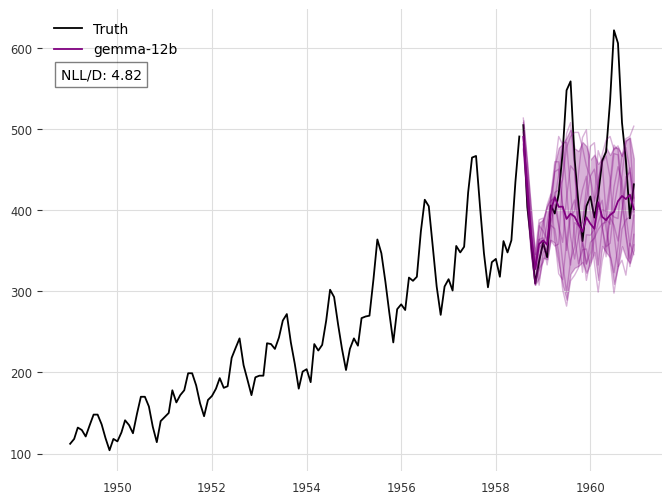

In [7]:
datasets = get_datasets()
ds_name = 'AirPassengersDataset'

data = datasets[ds_name]
train, test = data # or change to your own data
out = {}
for model in model_names: # GPT-4 takes a about a minute to run
    model_hypers[model].update({'dataset_name': ds_name}) # for promptcast
    hypers = list(grid_iter(model_hypers[model]))
    num_samples = 10
    pred_dict = get_autotuned_predictions_data(
        train,
        test,
        hypers,
        num_samples,
        model_predict_fns[model],
        verbose=False,
        parallel=False,
        chatgpt_sys_message=chatgpt_sys_message,
        few_shot_median=None
    )
    out[model] = pred_dict
    plot_preds(train, test, pred_dict, model, show_samples=True)

In [8]:
out

{'gemma-12b': {'samples': Month  1958-08-01  1958-09-01  1958-10-01  1958-11-01  1958-12-01  1959-01-01  \
  0        474.4548    417.0100    350.8236    308.1860    328.3452    377.9404   
  1        496.0412    441.8076    379.3676    336.0164    364.0252    359.7436   
  2        491.0460    413.0852    351.0020    307.8292    353.8564    359.2084   
  3        481.5908    437.8828    370.8044    327.4532    380.9732    374.3724   
  4        507.8156    453.7604    390.2500    345.2932    388.2876    390.2500   
  5        476.4172    418.7940    366.1660    331.1996    362.9548    386.5036   
  6        513.7028    460.0044    403.9868    347.0772    307.6508    347.9692   
  7        496.5764    436.6340    377.9404    327.6316    364.0252    365.9876   
  8        481.5908    403.9868    347.0772    309.6132    327.8100    336.0164   
  9        489.9756    417.3668    350.8236    308.3644    340.8332    354.9268   
  
  Month  1959-02-01  1959-03-01  1959-04-01  1959-05-01  ...